In [1]:
from imolcryff.calculator import DihedCalculator, load_g16scan
from imolcryff.io.rdkit import atoms2rdkit

from ase.io import read
from ase.visualize import view

from imolcryff.trainer import DihedTrainer
import matplotlib.pyplot as plt

/Users/srak/apl/imolcryff/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")


In [2]:
pdbfile = "dmc.pdb"
atoms = read(pdbfile)
mol, mol2d, _ = atoms2rdkit(atoms)
calculator = DihedCalculator(atoms, mol, "dmc" "temp_directory")
calculator.dihedral_list

[[1, 0, 2, 8], [1, 0, 3, 4], [0, 2, 8, 9], [0, 3, 4, 5]]

In [3]:
# check dihedral atom index -> 1,0,2,8
view(load_g16scan("dmc_dihed_0.log")[2])
# check dihedral atom index -> 0,2,8,9
view(load_g16scan("dmc_dihed_2.log")[2])

2025-05-07 23:20:47.792 python[54069:1675779] +[IMKClient subclass]: chose IMKClient_Modern
2025-05-07 23:20:47.792 python[54069:1675779] +[IMKInputSession subclass]: chose IMKInputSession_Modern


<Popen: returncode: None args: ['/Users/srak/miniconda3/envs/imc_dev/bin/pyt...>

In [4]:
calculator.dihedral_list  = [calculator.dihedral_list[0] , calculator.dihedral_list[2]]
calculator.qm_calculators = [calculator.qm_calculators[0], calculator.qm_calculators[2]]
calculator.ff_calculators = [calculator.ff_calculators[0], calculator.ff_calculators[2]]
calculator.qm_dihedscan = [calculator.qm_dihedscan[0], calculator.qm_dihedscan[2]]
calculator.ff_dihedscan = [calculator.ff_dihedscan[0], calculator.ff_dihedscan[2]]

calculator.qm_dihedscan[0]["angles_deg"], \
calculator.qm_dihedscan[0]["energies_kjmol"], \
calculator.qm_dihedscan[0]["atoms"], \
      = load_g16scan("dmc_dihed_0.log")

calculator.qm_dihedscan[1]["angles_deg"], \
calculator.qm_dihedscan[1]["energies_kjmol"], \
calculator.qm_dihedscan[1]["atoms"], \
      = load_g16scan("dmc_dihed_2.log")

2025-05-07 23:20:48.167 python[54070:1675904] +[IMKClient subclass]: chose IMKClient_Modern
2025-05-07 23:20:48.167 python[54070:1675904] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [5]:
tr = DihedTrainer(
    ffxml="dmc.xml",
    pdb=pdbfile,
    calculator=calculator,
)

In [6]:
tr.setup()

In [7]:
tr.fit(steps=1000, relax_steps=20)

epoch 0
loss 51.636418649594994
epoch 20
loss 5.095207060194773
epoch 40
loss 2.282016032845374
epoch 60
loss 1.2838907106125272
epoch 80
loss 0.6875311715113164
epoch 100
loss 0.41786292463215674
epoch 120
loss 0.2767377846270456
epoch 140
loss 0.2558035221734807
epoch 160
loss 0.24490609753280498
epoch 180
loss 0.22978899819162332
epoch 200
loss 0.22256658167327006
epoch 220
loss 0.22236569632624373
epoch 240
loss 0.20647170676494692
epoch 260
loss 0.20530140314414738
epoch 280
loss 0.19692571733923558
epoch 300
loss 0.1878531615119792
epoch 320
loss 0.18166913260645837
epoch 340
loss 0.1731974147660419
epoch 360
loss 0.1637981524855218
epoch 380
loss 0.15914994938750499
epoch 400
loss 0.15370155919429823
epoch 420
loss 0.1477538180180876
epoch 440
loss 0.13876586280539022
epoch 460
loss 0.13437520820186766


KeyboardInterrupt: 

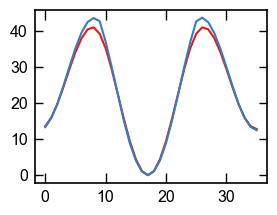

In [8]:
plt.plot(tr.calculator.qm_dihedscan[0]["energies_kjmol"])
plt.plot(tr.calculator.ff_dihedscan[0]["energies_kjmol"])

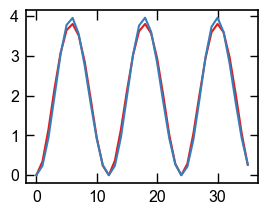

In [9]:
plt.plot(tr.calculator.qm_dihedscan[1]["energies_kjmol"])
plt.plot(tr.calculator.ff_dihedscan[1]["energies_kjmol"])